# 02_decode_msaa_flexible.ipynb

Flexible decoding notebook for spatial/temporal × within/across.

In [16]:

ANALYSIS_TYPE = "spatial"   # "spatial" or "temporal"
FIT_SCOPE = "within"         # "within" or "across"

LOAD_DIR = "msaa_flexible_outputs_npz"
OUTPUT_DIR = f"msaa_flexible_decoding_outputs_{ANALYSIS_TYPE}_{FIT_SCOPE}"

K_VALUES = [5, 10]
CONDITIONS = ["intact", "word", "rest"]

NFOLDS_DECODE = 2
NREPS_DECODE = 20
TOP_M_LIST = [1, 2, 3, 4, 5]
RNG_SEED = 42
ERRORBAR_TYPE = "sem"


In [17]:

%matplotlib inline
import os
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print("Ready.")
print("Output dir:", OUTPUT_DIR)


Ready.
Output dir: msaa_flexible_decoding_outputs_spatial_within


In [18]:

def to_float_array(x): return np.array(x, dtype=float)

def load_msaa_npz(path):
    data = np.load(path, allow_pickle=True)
    results_subj = data["results_subj"].tolist()
    if isinstance(results_subj, np.ndarray):
        results_subj = results_subj.tolist()
    return {"K": int(data["K"]), "results_subj": results_subj, "condition_labels_str": data["condition_labels_str"].tolist()}

def file_for_job(load_dir, analysis_type, fit_scope, K, cond_name=None):
    if fit_scope == "within":
        return os.path.join(load_dir, f"{analysis_type}AA_within_{cond_name}_K{K}.npz")
    return os.path.join(load_dir, f"{analysis_type}AA_across_acrossCond_K{K}.npz")

def reconstruct_subject(sub, analysis_type, top_indices=None):
    sXC = to_float_array(sub["sXC"]); S = to_float_array(sub["S"])
    if top_indices is None:
        Xhat = sXC @ S if analysis_type == "spatial" else (sXC @ S).T
    else:
        Xhat = (sXC[:, top_indices] @ S[top_indices, :]) if analysis_type == "spatial" else (sXC[:, top_indices] @ S[top_indices, :]).T
    return (Xhat - Xhat.mean(axis=0, keepdims=True)) / (Xhat.std(axis=0, keepdims=True) + 1e-8)

def build_recon_stack(subjects, analysis_type, top_indices=None):
    return np.stack([reconstruct_subject(sub, analysis_type, top_indices=top_indices) for sub in subjects], axis=0)

def decoder(corrs):
    out = pd.DataFrame({'rank':[0.0], 'accuracy':[0.0], 'error':[0.0]})
    T = corrs.shape[0]
    for t in range(T):
        decoded_ind = int(np.argmax(corrs[t, :]))
        out.loc[0,'error'] += np.mean(np.abs(decoded_ind - t)) / T
        out.loc[0,'accuracy'] += (decoded_ind == t)
        out.loc[0,'rank'] += np.mean((corrs[t, :] <= corrs[t, t]).astype(int))
    out['error'] /= T; out['accuracy'] /= T; out['rank'] /= T
    return out

def get_xval_assignments(ndata, nfolds, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    group_assignments = np.zeros(ndata, dtype=int)
    groupsize = int(np.ceil(ndata / nfolds))
    for i in range(1, nfolds):
        inds = np.arange(i * groupsize, min((i + 1) * groupsize, ndata))
        group_assignments[inds] = i
    rng.shuffle(group_assignments)
    return group_assignments

def run_timepoint_decoding(recon_stack, nfolds=2, nreps=20, seed=42):
    N,T,V = recon_stack.shape
    rng = np.random.default_rng(seed)
    all_results = []
    for rep in range(nreps):
        fold_ids = get_xval_assignments(N, nfolds, rng)
        for i in range(nfolds):
            in_mask = (fold_ids == i); out_mask = ~in_mask
            in_mean = recon_stack[in_mask].mean(axis=0); out_mean = recon_stack[out_mask].mean(axis=0)
            corrs = 1.0 - cdist(in_mean, out_mean, metric='correlation')
            res = decoder(corrs); res["rep"] = rep; res["fold"] = i
            all_results.append(res)
    return pd.concat(all_results, ignore_index=True)

def per_archetype_decoding(subjects, analysis_type, nfolds=2, nreps=20, seed=42):
    K = to_float_array(subjects[0]["sXC"]).shape[1]
    rows = []
    for k in range(K):
        recon_stack = build_recon_stack(subjects, analysis_type, top_indices=[k])
        res = run_timepoint_decoding(recon_stack, nfolds, nreps, seed)
        res["archetype"] = k
        rows.append(res)
    return pd.concat(rows, ignore_index=True)

def run_timepoint_decoding_topm(subjects, analysis_type, ranked_indices, top_ms, nfolds=2, nreps=20, seed=42):
    rows = []
    for m in top_ms:
        recon_stack = build_recon_stack(subjects, analysis_type, top_indices=ranked_indices[:m])
        res = run_timepoint_decoding(recon_stack, nfolds, nreps, seed)
        res["top_m"] = m
        rows.append(res)
    return pd.concat(rows, ignore_index=True)

def summarize_metric_with_error(df, metric_col, errorbar_type="sem", group_cols=None):
    group_cols = [] if group_cols is None else group_cols
    out = df.groupby(group_cols)[metric_col].agg(["mean", "std", "count"]).reset_index()
    if errorbar_type == "sem":
        out["err"] = out["std"] / np.sqrt(out["count"].clip(lower=1))
    elif errorbar_type == "std":
        out["err"] = out["std"]
    else:
        out["err"] = 1.96 * out["std"] / np.sqrt(out["count"].clip(lower=1))
    return out


In [19]:

full_recon_rows = []
topm_rows = []
per_arch_summary_rows = []
rankings = {}

if FIT_SCOPE == "within":
    for cond_name in CONDITIONS:
        for K in K_VALUES:
            cur = load_msaa_npz(file_for_job(LOAD_DIR, ANALYSIS_TYPE, FIT_SCOPE, K, cond_name))
            results_subj = cur["results_subj"]
            print(f"Decoding {ANALYSIS_TYPE}AA | within | {cond_name} | K={K} | n={len(results_subj)}")
            recon_stack = build_recon_stack(results_subj, ANALYSIS_TYPE)
            res_full = run_timepoint_decoding(recon_stack, NFOLDS_DECODE, NREPS_DECODE, RNG_SEED)
            res_full["condition"] = cond_name; res_full["K"] = K; res_full["reconstruction"] = "all_archetypes"
            full_recon_rows.append(res_full)
            per_arch = per_archetype_decoding(results_subj, ANALYSIS_TYPE, NFOLDS_DECODE, NREPS_DECODE, RNG_SEED)
            top_arch = per_arch.groupby("archetype")["accuracy"].mean().sort_values(ascending=False)
            rankings[(cond_name, K)] = top_arch.index.to_numpy()
            pa = top_arch.reset_index(); pa.columns = ["archetype", "mean_accuracy"]; pa["condition"] = cond_name; pa["K"] = K
            per_arch_summary_rows.append(pa)
            res_topm = run_timepoint_decoding_topm(results_subj, ANALYSIS_TYPE, rankings[(cond_name, K)], TOP_M_LIST, NFOLDS_DECODE, NREPS_DECODE, RNG_SEED)
            res_topm["condition"] = cond_name; res_topm["K"] = K; res_topm["reconstruction"] = "top_m_within_condition"
            topm_rows.append(res_topm)
else:
    for K in K_VALUES:
        cur = load_msaa_npz(file_for_job(LOAD_DIR, ANALYSIS_TYPE, FIT_SCOPE, K))
        results_subj = cur["results_subj"]; condition_labels_str = np.array(cur["condition_labels_str"])
        print(f"Decoding {ANALYSIS_TYPE}AA | across | K={K} | n={len(results_subj)}")
        for cond_name in sorted(np.unique(condition_labels_str)):
            idx = np.where(condition_labels_str == cond_name)[0]
            sub_cond = [results_subj[i] for i in idx]
            recon_stack = build_recon_stack(sub_cond, ANALYSIS_TYPE)
            res_full = run_timepoint_decoding(recon_stack, NFOLDS_DECODE, NREPS_DECODE, RNG_SEED)
            res_full["condition"] = cond_name; res_full["K"] = K; res_full["reconstruction"] = "all_archetypes"
            full_recon_rows.append(res_full)
        per_arch = per_archetype_decoding(results_subj, ANALYSIS_TYPE, NFOLDS_DECODE, NREPS_DECODE, RNG_SEED)
        top_arch = per_arch.groupby("archetype")["accuracy"].mean().sort_values(ascending=False)
        rankings[K] = top_arch.index.to_numpy()
        pa = top_arch.reset_index(); pa.columns = ["archetype", "mean_accuracy"]; pa["condition"] = "across_all_subjects"; pa["K"] = K
        per_arch_summary_rows.append(pa)
        for cond_name in sorted(np.unique(condition_labels_str)):
            idx = np.where(condition_labels_str == cond_name)[0]
            sub_cond = [results_subj[i] for i in idx]
            res_topm = run_timepoint_decoding_topm(sub_cond, ANALYSIS_TYPE, rankings[K], TOP_M_LIST, NFOLDS_DECODE, NREPS_DECODE, RNG_SEED)
            res_topm["condition"] = cond_name; res_topm["K"] = K; res_topm["reconstruction"] = "top_m_across_condition_ranked"
            topm_rows.append(res_topm)

full_recon_df = pd.concat(full_recon_rows, ignore_index=True)
topm_df = pd.concat(topm_rows, ignore_index=True)
per_arch_summary_df = pd.concat(per_arch_summary_rows, ignore_index=True)

full_summary = summarize_metric_with_error(full_recon_df, "accuracy", ERRORBAR_TYPE, ["condition", "K", "reconstruction"])
topm_summary = summarize_metric_with_error(topm_df, "accuracy", ERRORBAR_TYPE, ["condition", "K", "reconstruction", "top_m"])

best_topm_rows = []
for cond_name in CONDITIONS:
    for K in K_VALUES:
        sub = topm_summary[(topm_summary["condition"] == cond_name) & (topm_summary["K"] == K)]
        if len(sub):
            best_topm_rows.append(sub.loc[sub["mean"].idxmax()].copy())
best_topm_df = pd.DataFrame(best_topm_rows)

topm_rows_meta = []
if FIT_SCOPE == "within":
    for cond_name in CONDITIONS:
        for K in K_VALUES:
            ranked = rankings[(cond_name, K)]
            for m in TOP_M_LIST:
                topm_rows_meta.append({"condition": cond_name, "K": K, "top_m": m, "selected_archetypes": list(ranked[:m]), "selected_archetypes_str": str(list(ranked[:m]))})
else:
    for K in K_VALUES:
        ranked = rankings[K]
        for cond_name in CONDITIONS:
            for m in TOP_M_LIST:
                topm_rows_meta.append({"condition": cond_name, "K": K, "top_m": m, "selected_archetypes": list(ranked[:m]), "selected_archetypes_str": str(list(ranked[:m]))})
topm_archetypes_df = pd.DataFrame(topm_rows_meta)

full_recon_df.to_csv(os.path.join(OUTPUT_DIR, "full_reconstruction_runs.csv"), index=False)
topm_df.to_csv(os.path.join(OUTPUT_DIR, "topm_runs.csv"), index=False)
per_arch_summary_df.to_csv(os.path.join(OUTPUT_DIR, "per_archetype_mean_accuracy.csv"), index=False)
full_summary.to_csv(os.path.join(OUTPUT_DIR, "full_reconstruction_summary.csv"), index=False)
topm_summary.to_csv(os.path.join(OUTPUT_DIR, "topm_summary.csv"), index=False)
best_topm_df.to_csv(os.path.join(OUTPUT_DIR, "best_topm_summary.csv"), index=False)
topm_archetypes_df.to_csv(os.path.join(OUTPUT_DIR, "topm_archetype_identities.csv"), index=False)
np.save(os.path.join(OUTPUT_DIR, "rankings.npy"), rankings, allow_pickle=True)

display(full_summary)
display(topm_summary.head())
display(best_topm_df)
print("Saved to:", OUTPUT_DIR)


Decoding spatialAA | within | intact | K=5 | n=36
Decoding spatialAA | within | intact | K=10 | n=36
Decoding spatialAA | within | word | K=5 | n=36
Decoding spatialAA | within | word | K=10 | n=36
Decoding spatialAA | within | rest | K=5 | n=36
Decoding spatialAA | within | rest | K=10 | n=36


,condition,K,reconstruction,mean,std,count,err
0,intact,5,all_archetypes,0.038667,0.008433,40,0.001333
1,intact,10,all_archetypes,0.062250,0.012685,40,0.002006
2,rest,5,all_archetypes,0.005750,0.004401,40,0.000696
3,rest,10,all_archetypes,0.006333,0.004051,40,0.000641
4,word,5,all_archetypes,0.020667,0.006546,40,0.001035
5,word,10,all_archetypes,0.030583,0.007196,40,0.001138


,condition,K,reconstruction,top_m,mean,std,count,err
0,intact,5,top_m_within_condition,1,0.007917,0.003515,40,0.000556
1,intact,5,top_m_within_condition,2,0.022250,0.005411,40,0.000856
2,intact,5,top_m_within_condition,3,0.029833,0.007806,40,0.001234
3,intact,5,top_m_within_condition,4,0.034417,0.007675,40,0.001214
4,intact,5,top_m_within_condition,5,0.038667,0.008433,40,0.001333


,condition,K,reconstruction,top_m,mean,std,count,err
4,intact,5,top_m_within_condition,5,0.038667,0.008433,40,0.001333
9,intact,10,top_m_within_condition,5,0.033083,0.008282,40,0.001310
23,word,5,top_m_within_condition,4,0.025250,0.007841,40,0.001240
29,word,10,top_m_within_condition,5,0.028833,0.007973,40,0.001261
11,rest,5,top_m_within_condition,2,0.007667,0.003789,40,0.000599
16,rest,10,top_m_within_condition,2,0.009083,0.004335,40,0.000685


Saved to: msaa_flexible_decoding_outputs_spatial_within



## Decoding plots

These cells plot the decoding results saved in this notebook.

- For **within-condition** runs:
  - full reconstruction decoding vs `K`
  - top-`m` decoding vs `K`, separately for each condition

- For **across-condition** runs:
  - full reconstruction decoding vs `K` by condition
  - top-`m` decoding vs `K` by condition


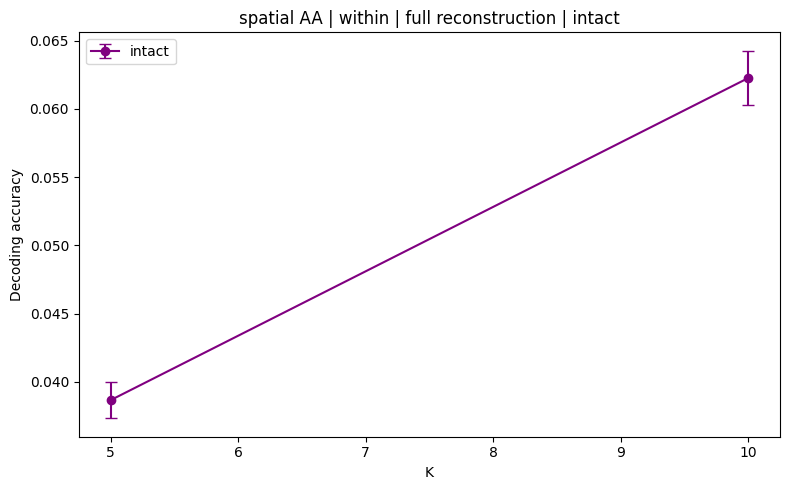

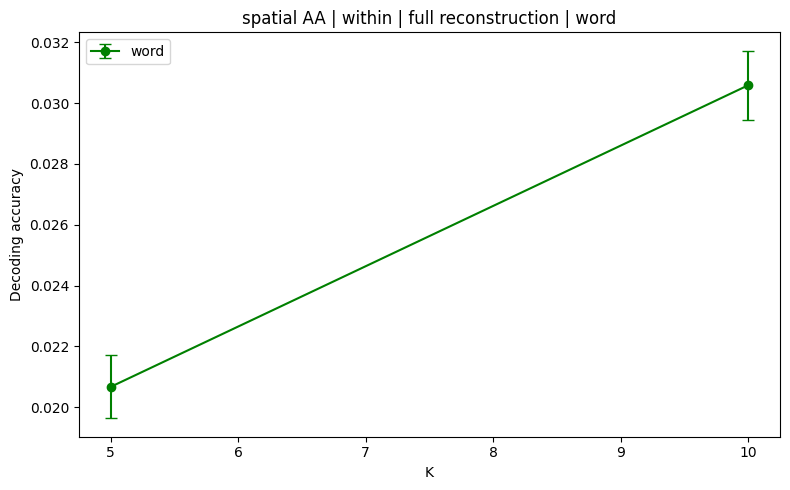

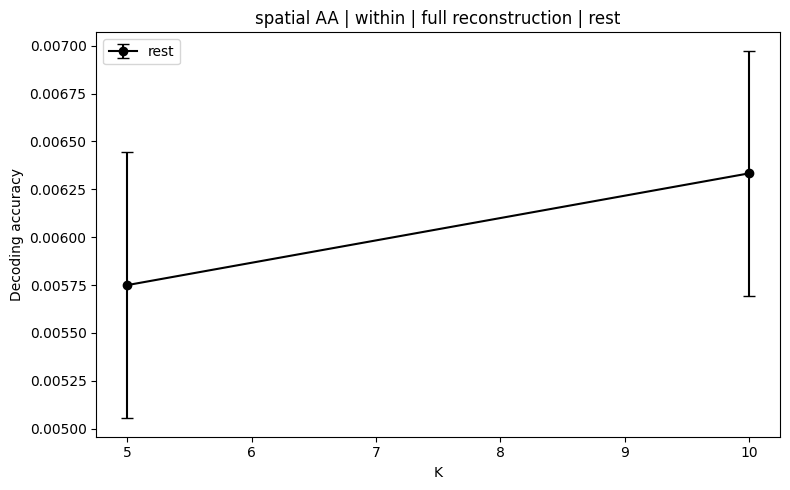

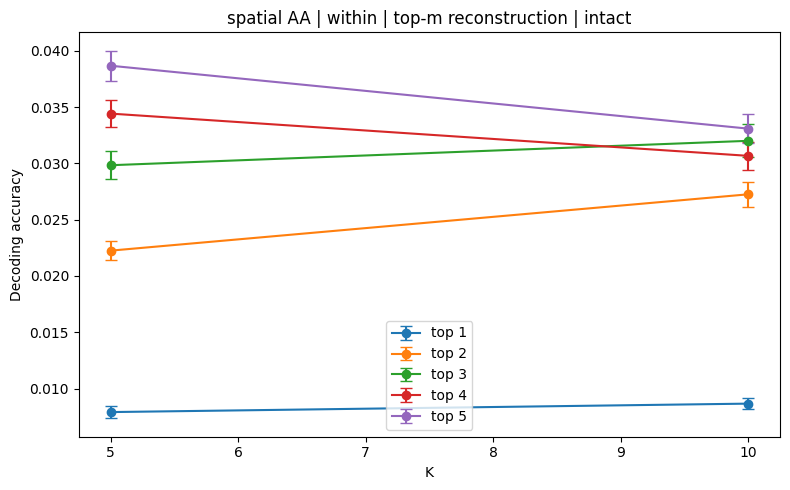

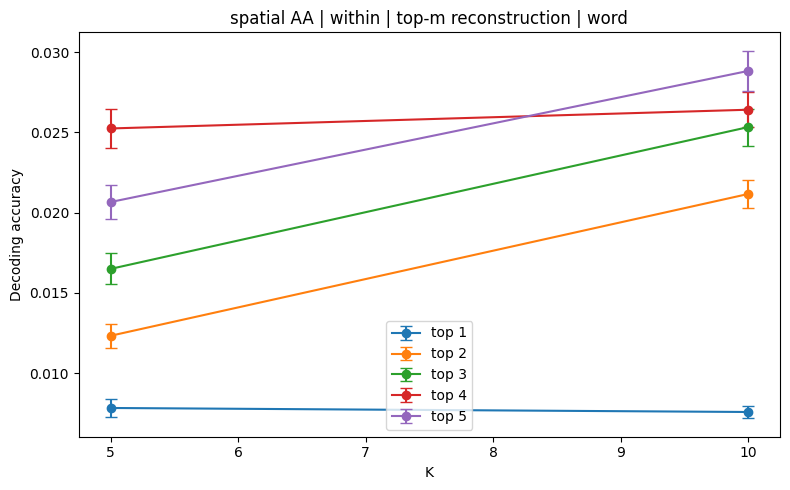

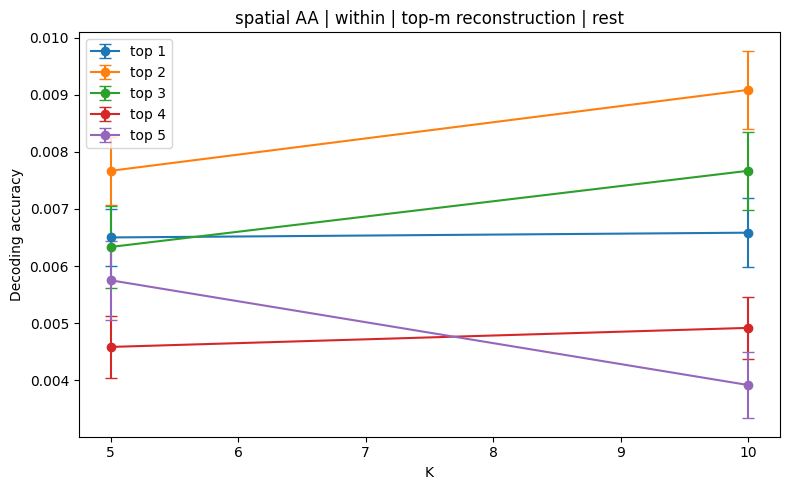

In [20]:

COND_PLOT_COLORS = {"intact": "purple", "word": "green", "rest": "black"}

if FIT_SCOPE == "within":
    # Full reconstruction curves, one panel per condition
    for cond_name in CONDITIONS:
        sub = full_summary[full_summary["condition"] == cond_name].sort_values("K")
        if len(sub) == 0:
            continue
        plt.figure(figsize=(8, 5))
        plt.errorbar(
            sub["K"], sub["mean"], yerr=sub["err"],
            marker="o", capsize=4,
            color=COND_PLOT_COLORS.get(cond_name, "black"),
            label=cond_name
        )
        plt.xlabel("K")
        plt.ylabel("Decoding accuracy")
        plt.title(f"{ANALYSIS_TYPE} AA | within | full reconstruction | {cond_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Top-m curves, one panel per condition
    for cond_name in CONDITIONS:
        cond_df = topm_summary[topm_summary["condition"] == cond_name].sort_values(["top_m", "K"])
        if len(cond_df) == 0:
            continue
        plt.figure(figsize=(8, 5))
        for top_m in sorted(cond_df["top_m"].unique()):
            sub = cond_df[cond_df["top_m"] == top_m].sort_values("K")
            plt.errorbar(
                sub["K"], sub["mean"], yerr=sub["err"],
                marker="o", capsize=4, label=f"top {top_m}"
            )
        plt.xlabel("K")
        plt.ylabel("Decoding accuracy")
        plt.title(f"{ANALYSIS_TYPE} AA | within | top-m reconstruction | {cond_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()

else:
    # Full reconstruction curves, all conditions together
    plt.figure(figsize=(8, 5))
    for cond_name in CONDITIONS:
        sub = full_summary[full_summary["condition"] == cond_name].sort_values("K")
        if len(sub) == 0:
            continue
        plt.errorbar(
            sub["K"], sub["mean"], yerr=sub["err"],
            marker="o", capsize=4,
            color=COND_PLOT_COLORS.get(cond_name, "black"),
            label=cond_name
        )
    plt.xlabel("K")
    plt.ylabel("Decoding accuracy")
    plt.title(f"{ANALYSIS_TYPE} AA | across | full reconstruction by condition")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Top-m curves, one panel per condition
    for cond_name in CONDITIONS:
        cond_df = topm_summary[topm_summary["condition"] == cond_name].sort_values(["top_m", "K"])
        if len(cond_df) == 0:
            continue
        plt.figure(figsize=(8, 5))
        for top_m in sorted(cond_df["top_m"].unique()):
            sub = cond_df[cond_df["top_m"] == top_m].sort_values("K")
            plt.errorbar(
                sub["K"], sub["mean"], yerr=sub["err"],
                marker="o", capsize=4, label=f"top {top_m}"
            )
        plt.xlabel("K")
        plt.ylabel("Decoding accuracy")
        plt.title(f"{ANALYSIS_TYPE} AA | across | top-m reconstruction | {cond_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()
